- From noiseless to DC2 images
- Test of different architecture
- Impact of usage of PSF
- Impact of usage of fft
- First diff on Bayesian neural network

- noisy images

Test are done with sample up to 24.5 magnitude

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

W0525 15:50:59.445105 140130899924800 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


## Load data

In [2]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/' # mag cut at 24.5 in r band
#root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_26.5/' # mag cut at 26.5 in r band

## Load transformations of ellipticities

### for inputs

In [3]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

## Load models

### Loading directories

In [4]:
root_dir_models = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'

dir_model_v2 = root_dir_models+'v_test_noisy/weights_0_step_150/end_step/'#'v14/loss/'  # concat only after all convolution blocks
dir_model_v3 = root_dir_models+'v15_noisy/bis_bis/mse/'#'v15/loss/'  # No use of PSF
dir_model_v5 = root_dir_models+'v17_noisy/bis/loss/'#'v17/loss/'  # BNN with concat after all convolution blocks


### Set models parameters

In [5]:
######## Parameters
nb_of_bands = 6
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

### Define and load models

In [6]:
model_concat_one = model.create_model_wo_ls_peak_pooling_concat_one(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
model_no_psf = model.create_model_wo_ls_peak_pooling_no_psf(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
model_bnn = model.create_model_prob_flipout_peak(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0525 15:20:28.742181 140254560290624 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0525 15:20:29.735259 140254560290624 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.
W0525 15:20:30.851427 140254560290624 deprecation.py:323] From ../../scripts/tools_for_VAE/tool

[8192, 256]
Tensor("dense_flipout/Size:0", shape=(), dtype=int32)
[256, 5]
Tensor("dense_flipout_1/Size:0", shape=(), dtype=int32)


In [8]:
latest = tf.train.latest_checkpoint(dir_model_v2)
model_concat_one.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v3)
model_no_psf.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v5)
model_bnn.load_weights(latest)

## Training magnitude cut at 24.5 in $r$-band

### Noiseless images

### Load data 

In [9]:
images = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])


ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, shear_1, shear_2, convergence))

In [10]:
np.max(e1), np.max(e2)

(0.9820585314657808, 0.9534486586667172)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
id                10000 non-null int64
e1                10000 non-null float64
e2                10000 non-null float64
shear_1           10000 non-null float64
shear_2           10000 non-null float64
redshift          10000 non-null float64
redshift_true     10000 non-null float64
blendedness       9999 non-null float64
snr_r             9998 non-null float64
convergence       10000 non-null float64
e1_hsm_regauss    9976 non-null float64
e2_hsm_regauss    9976 non-null float64
mag_r_meas        9998 non-null float64
mag_r_true        10000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


## Test of models

In [12]:
nb_of_points = 1000

In [17]:
output_v1 = model_concat_one([tf.cast(images[:nb_of_points], tf.float32), tf.cast(psf[:nb_of_points], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

Text(0.5, 1.0, '$e2$')

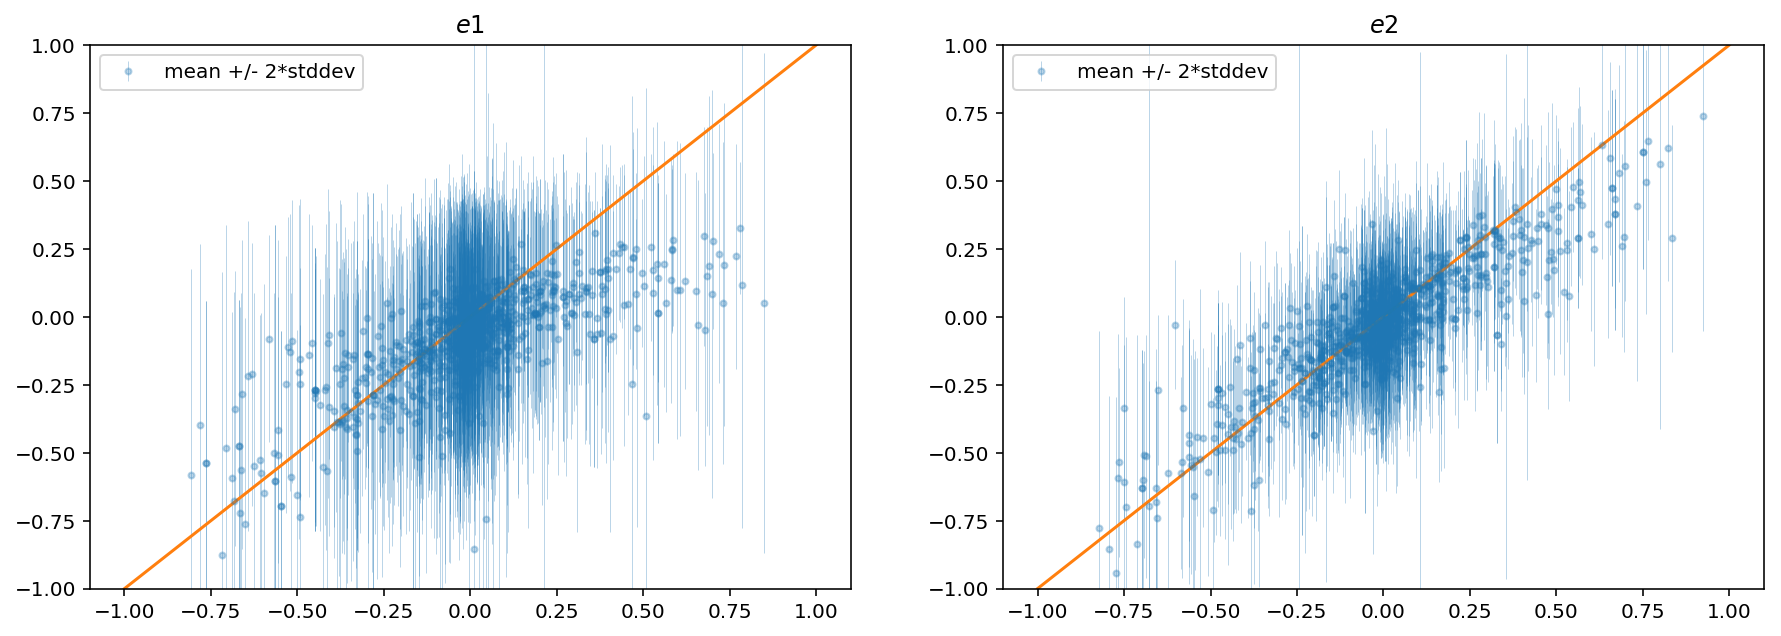

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(-e1[:nb_of_points], e1_out_mean, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].errorbar(e2[:nb_of_points], e2_out_mean, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

Text(0.5, 0, '$e_2$ truth')

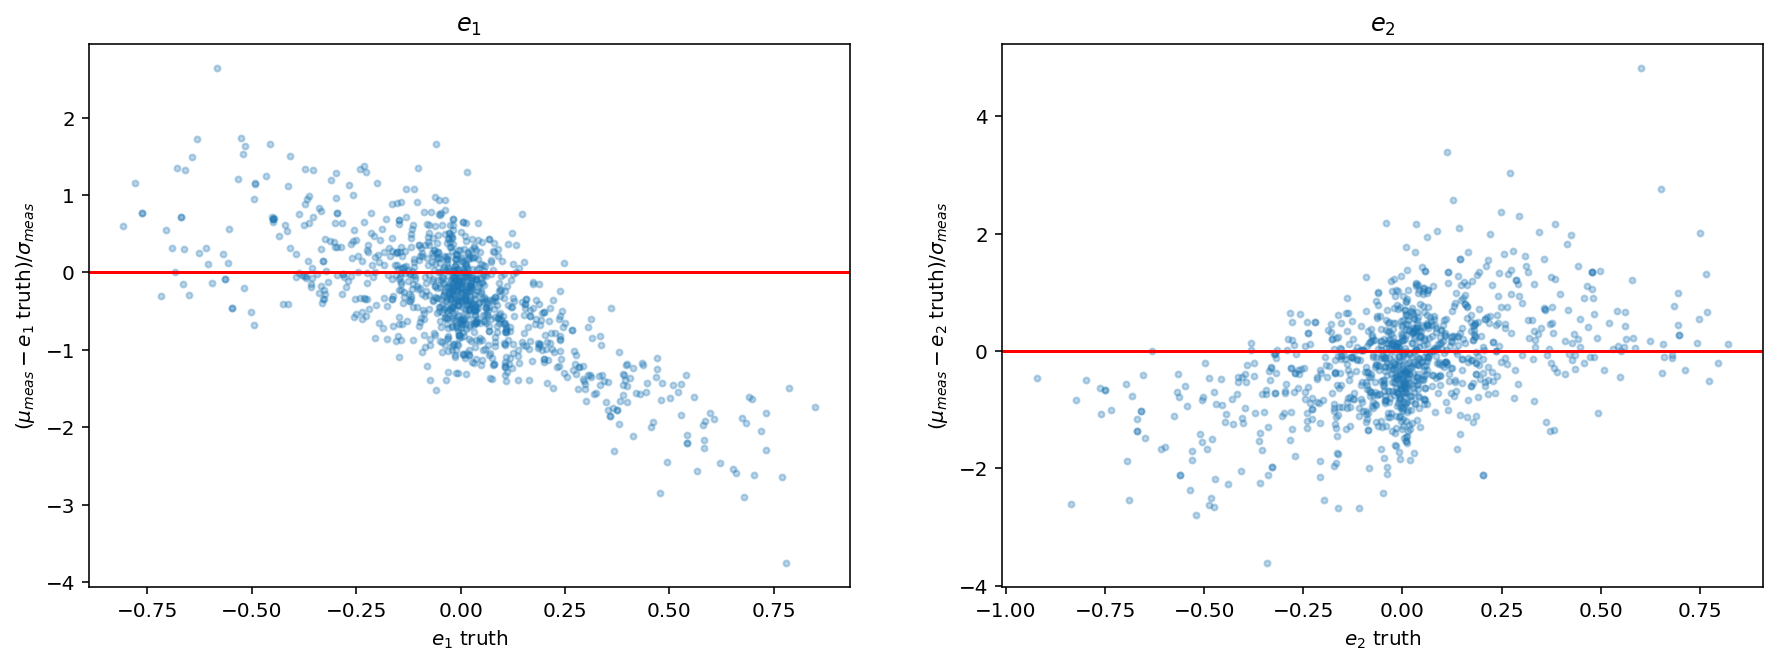

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(-e1[:nb_of_points], (e1_out_mean+e1[:nb_of_points])/e1_out_std, '.',label = 'mean +/- 2*stddev', alpha = 0.3)
#x = np.linspace(-1,1)
#axes[0].plot(x, x)
axes[0].axhline(0, color = 'r')
#axes[0].legend()
#axes[0].set_ylim(-1,1)
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)/$\sigma_{meas}$')
axes[0].set_xlabel('$e_1$ truth')

axes[1].plot(-e2[:nb_of_points], (e2_out_mean-e2[:nb_of_points])/e2_out_std, '.',label = 'mean +/- 2*stddev', alpha = 0.3)
#x = np.linspace(-1,1)
#axes[1].plot(x, x)
#axes[1].legend()
axes[1].axhline(0, color = 'r')
#axes[1].set_ylim(-1,1)
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)/$\sigma_{meas}$')

axes[1].set_xlabel('$e_2$ truth')

In [67]:
#np.save('data/net_bnn_noisy.npy', (e1_out_mean,e2_out_mean,e1_out_std,e2_out_std))
np.save('data/net_once_concat_noisy.npy', (e1_out_mean,e2_out_mean,e1_out_std,e2_out_std))
#np.save('data/net_no_psf_noisy.npy', (e1_out_mean,e2_out_mean,e1_out_std,e2_out_std))

### Load saved results

In [68]:
e1_out_mean_once_concat, e2_out_mean_once_concat, e1_out_std_once_concat, e2_out_std_once_concat = np.load('data/net_once_concat_noisy.npy')
#e1_out_mean_all_concat, e2_out_mean_all_concat, e1_out_std_all_concat, e2_out_std_all_concat = np.load('data/net_all_concat.npy')
#e1_out_mean_bnn, e2_out_mean_bnn, e1_out_std_bnn, e2_out_std_bnn = np.load('data/net_bnn_noisy.npy')
e1_out_mean_no_psf, e2_out_mean_no_psf, e1_out_std_no_psf, e2_out_std_no_psf = np.load('data/net_no_psf_noisy.npy')
#e1_out_mean_one_concat_dense, e2_out_mean_one_concat_dense, e1_out_std_one_concat_dense, e2_out_std_one_concat_dense = np.load('data/net_one_concat_dense.npy')

In [69]:
nb_of_points = 1000

Std as function of SNR: how does aleatoric uncertainty react to SNR ?

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(data['snr_r'][:nb_of_points], e1_out_std_once_concat, '.', alpha = 0.3, label = 'with psf')
axes[0].plot(data['snr_r'][:nb_of_points], e1_out_std_no_psf, '.', alpha = 0.3, label = 'without psf')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('SNR')
axes[0].set_ylabel('std $e_1$')
axes[0].set_title('$e_1$')
axes[0].legend()

axes[1].plot(data['snr_r'][:nb_of_points], e2_out_std_once_concat, '.', alpha = 0.3, label = 'with psf')
axes[1].plot(data['snr_r'][:nb_of_points], e2_out_std_no_psf, '.', alpha = 0.3, label = 'without psf')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('SNR')
axes[1].set_ylabel('std $e_2$')
axes[1].set_title('$e_2$')
axes[1].legend()

Models comparison

In [20]:
mean_results_e1 = [e1_out_mean_once_concat,e1_out_mean_bnn,e1_out_mean_no_psf]
std_results_e1 = [e1_out_std_once_concat,e1_out_std_bnn,e1_out_std_no_psf]

mean_results_e2 = [e2_out_mean_once_concat,e2_out_mean_bnn,e2_out_mean_no_psf]
std_results_e2 = [e2_out_std_once_concat,e2_out_std_bnn,e2_out_std_no_psf]

labels=['det one concat', 'BNN', 'det no psf']

NameError: name 'e1_out_mean_bnn' is not defined

In [21]:
mean_results_e1 = [e1_out_mean_once_concat,e1_out_mean_no_psf]
std_results_e1 = [e1_out_std_once_concat,e1_out_std_no_psf]

mean_results_e2 = [e2_out_mean_once_concat,e2_out_mean_no_psf]
std_results_e2 = [e2_out_std_once_concat,e2_out_std_no_psf]

labels=['det one concat', 'det no psf']

In [22]:
def compar_models(mean_results_e1, mean_results_e2,e1_out_std,e2_out_std, param, xlim, labels, log = True):
    
    fig, axes = plt.subplots(3,3, figsize = (24,12))

    for i, res in enumerate (mean_results_e1):
        if log:
            bins=np.logspace(np.log10(xlim[0]),np.log10(xlim[1]), 11)

            axes[0,0].set_xscale('log')
            axes[0,1].set_xscale('log')
            axes[0,2].set_xscale('log')
            axes[1,1].set_xscale('log')
            axes[1,0].set_xscale('log')
            axes[1,2].set_xscale('log')
            axes[2,1].set_xscale('log')
            axes[2,0].set_xscale('log')
            axes[2,2].set_xscale('log')
        else:
            bins=np.linspace(xlim[0],xlim[1],11)

        axes[0,0].set_xlim(xlim)
        axes[0,1].set_xlim(xlim)
        axes[0,2].set_xlim(xlim)
        axes[1,1].set_xlim(xlim)
        axes[1,0].set_xlim(xlim)
        axes[1,2].set_xlim(xlim) 
        axes[2,1].set_xlim(xlim)
        axes[2,0].set_xlim(xlim)
        axes[2,2].set_xlim(xlim) 

        bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (mean_results_e1[i]+e1[:nb_of_points])/e1_out_std[i], statistic='mean', bins=bins)
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (mean_results_e1[i]+e1[:nb_of_points])/e1_out_std[i], statistic='std', bins=bins)
        bin_centers = np.zeros(10)
        for k in range(10):
            bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
            
        axes[0,0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[0,0].hlines(0,xmin = 0,xmax=np.max(data[param]) , color='red', alpha = 0.4)
        axes[0,0].legend()
        axes[0,0].set_title('mean $e_1$')
        
        axes[1,0].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[1,0].set_title('std of means $e_1$')
        
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], std_results_e1[i], statistic='mean', bins=bins)
        axes[2,0].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[2,0].set_title('mean uncertainty $e_1$')
        
        bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (mean_results_e2[i]+e2[:nb_of_points])/e2_out_std[i], statistic='mean', bins=bins)
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (mean_results_e2[i]+e2[:nb_of_points])/e2_out_std[i], statistic='std', bins=bins)
        bin_centers = np.zeros(10)
        for k in range(10):
            bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
            
        axes[0,1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[0,1].hlines(0,xmin = 0,xmax=np.max(data[param]) , color='red', alpha = 0.4)
        axes[0,1].legend()
        axes[0,1].set_title('mean $e_2$')
        axes[1,1].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[1,1].set_title('std of means $e_2$')
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], std_results_e2[i], statistic='mean', bins=bins)
        axes[2,1].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[2,1].set_title('mean uncertainty $e_2$')

        e = np.sqrt(e1[:nb_of_points]**2+e2[:nb_of_points]**2)
        e_out = np.sqrt(mean_results_e1[i]**2+mean_results_e2[i]**2)
        std_sqrt = np.sqrt(std_results_e1[i]**2+std_results_e2[i]**2)
        e_std = np.sqrt(e1_out_std[i]**2+e2_out_std[i]**2)

        bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points],(e_out-e)/e_std, statistic='mean', bins=bins)
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (e_out-e)/e_std, statistic='std', bins=bins)
        bin_centers = np.zeros(10)
        for k in range(10):
            bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
            
        axes[0,2].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[0,2].hlines(0,xmin = 0,xmax=np.max(data[param]) , color='red', alpha = 0.4)
        axes[0,2].legend()
        axes[0,2].set_title('mean e')
        axes[1,2].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[1,2].set_title('std of means e')
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], e_std, statistic='mean', bins=bins)
        axes[2,2].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[2,2].set_title('mean uncertainty e')

In [23]:
e = np.sqrt(e1**2+e2**2)
data['e']=e

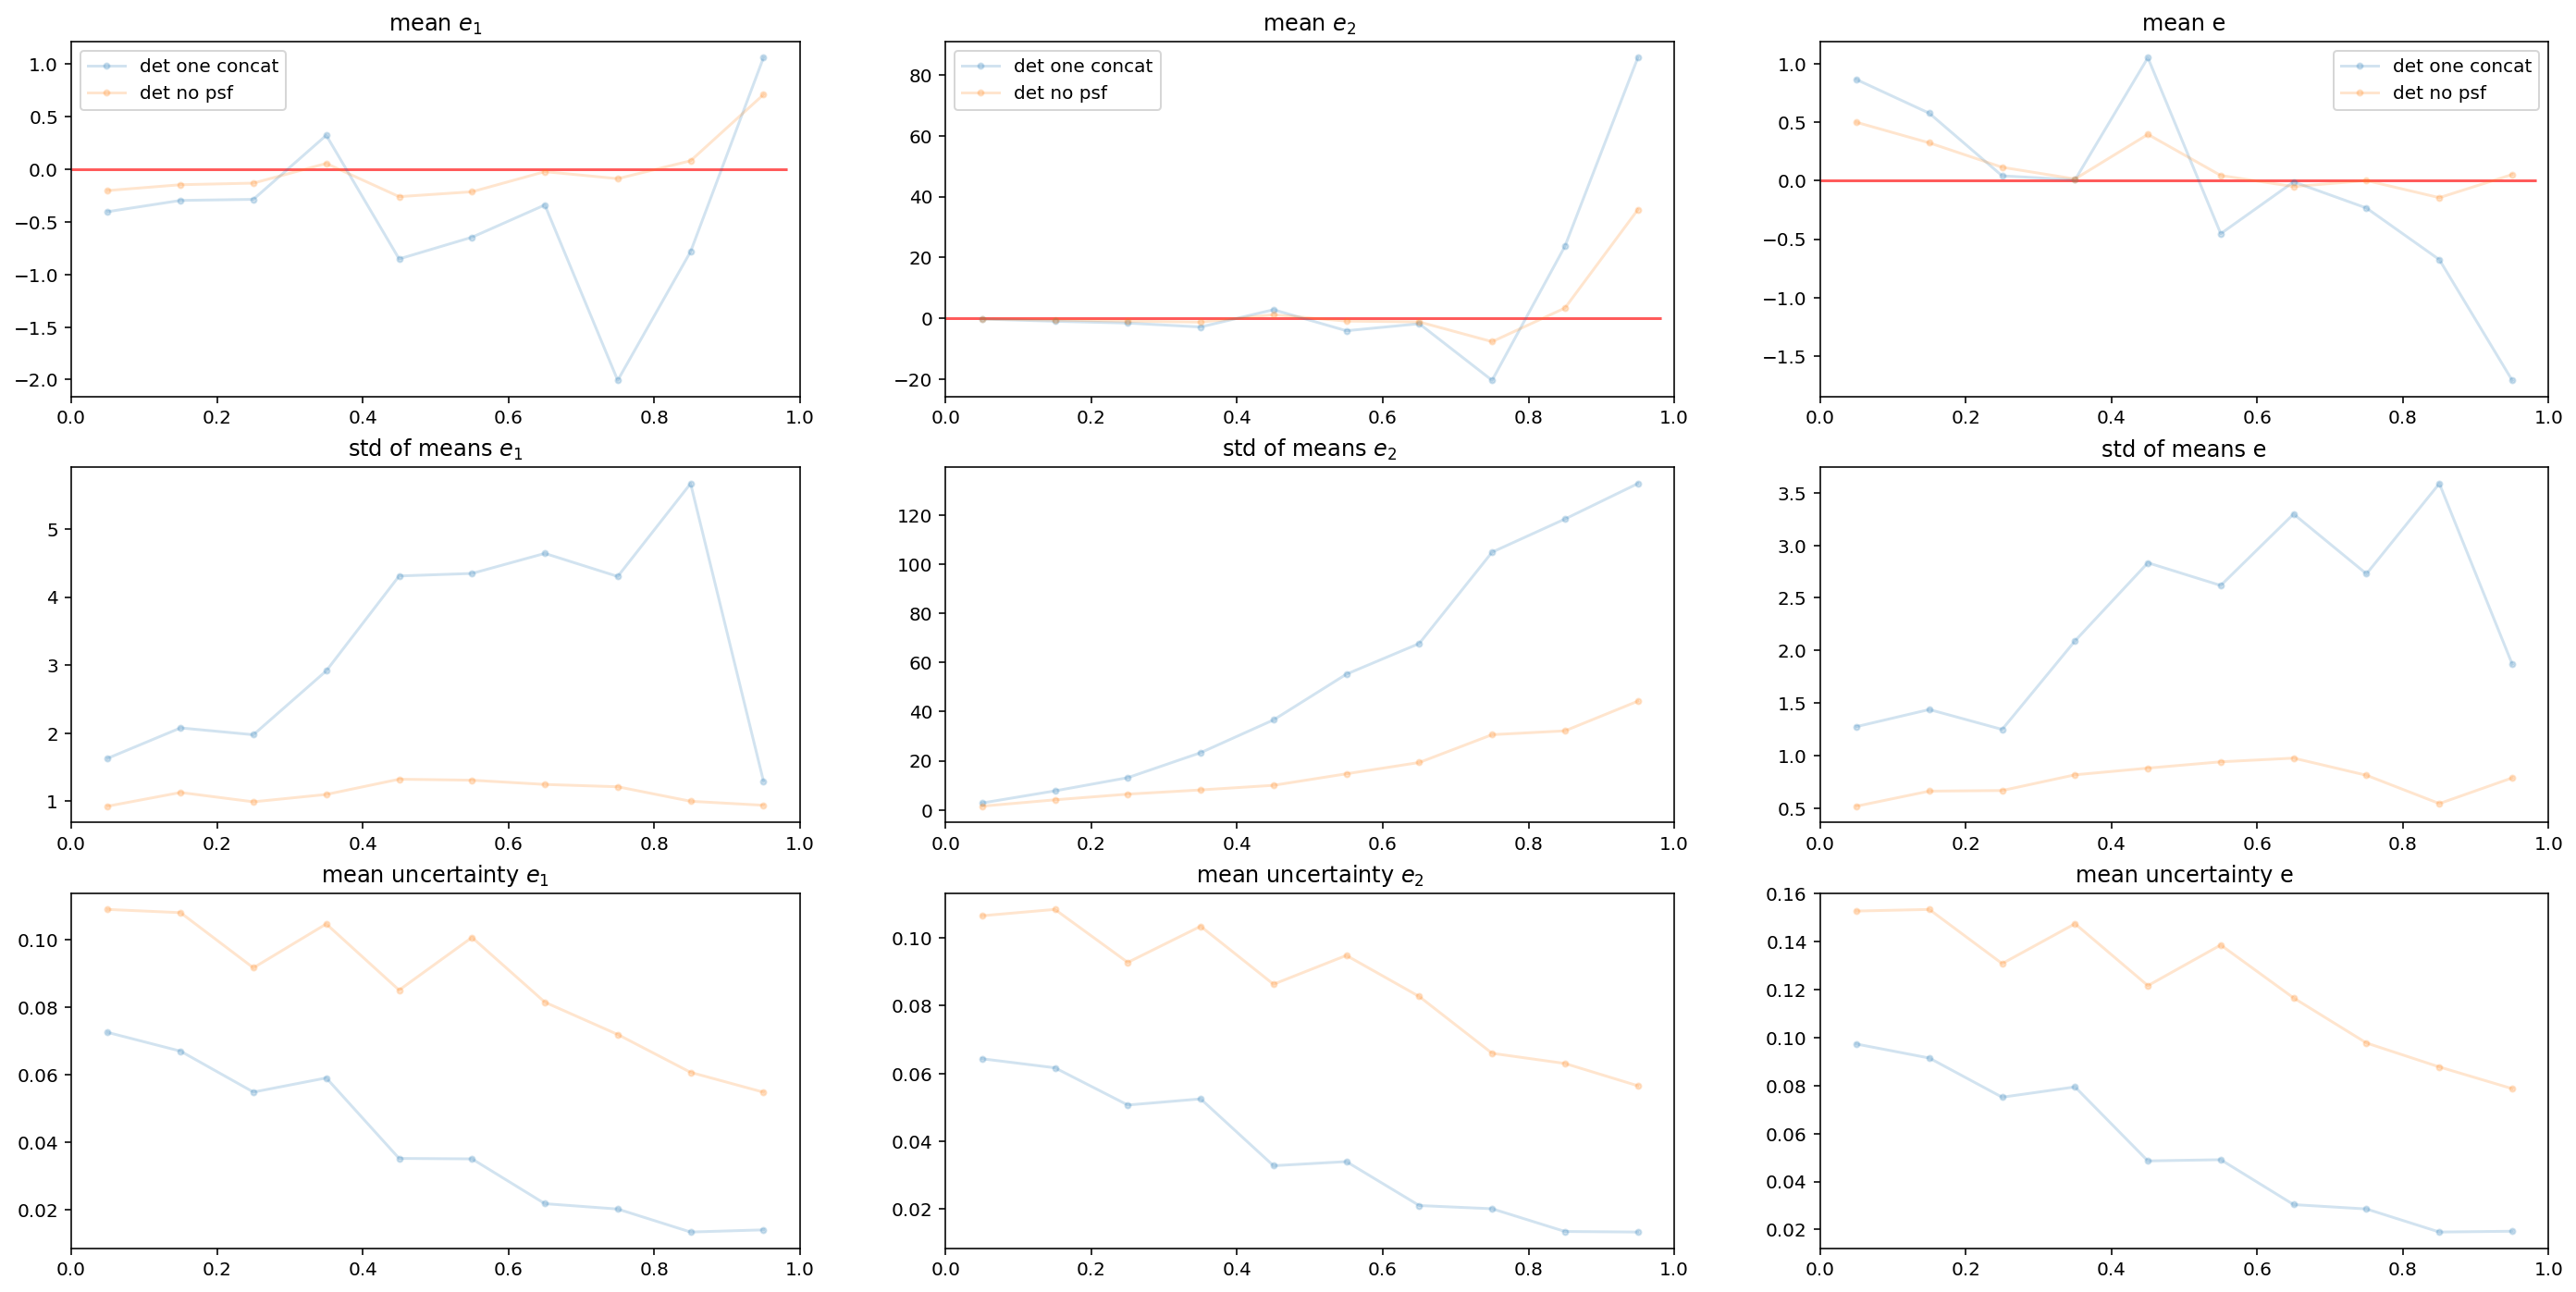

In [24]:
compar_models(mean_results_e1, mean_results_e2,std_results_e1,std_results_e2, 'e', xlim = (0,1), labels=labels, log = False)

## Test on images : noisy images

In [12]:
mean_results_e1 = [e1_out_mean_once_concat,e1_out_mean_bnn,e1_out_mean_no_psf]
std_results_e1 = [e1_out_std_once_concat,e1_out_std_bnn,e1_out_std_no_psf]

mean_results_e2 = [e2_out_mean_once_concat,e2_out_mean_bnn,e2_out_mean_no_psf]
std_results_e2 = [e2_out_std_once_concat,e2_out_std_bnn,e2_out_std_no_psf]

labels=['det one concat', 'BNN', 'det no psf']

In [25]:
mean_results_e1 = [e1_out_mean_once_concat,e1_out_mean_no_psf]
std_results_e1 = [e1_out_std_once_concat,e1_out_std_no_psf]

mean_results_e2 = [e2_out_mean_once_concat,e2_out_mean_no_psf]
std_results_e2 = [e2_out_std_once_concat,e2_out_std_no_psf]

labels=['det one concat',  'det no psf']

In [26]:
def gaussian(mean,std):
    return (1/(std*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean)/(2*std**2)))

In [27]:
images = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c')
images_noisy = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')

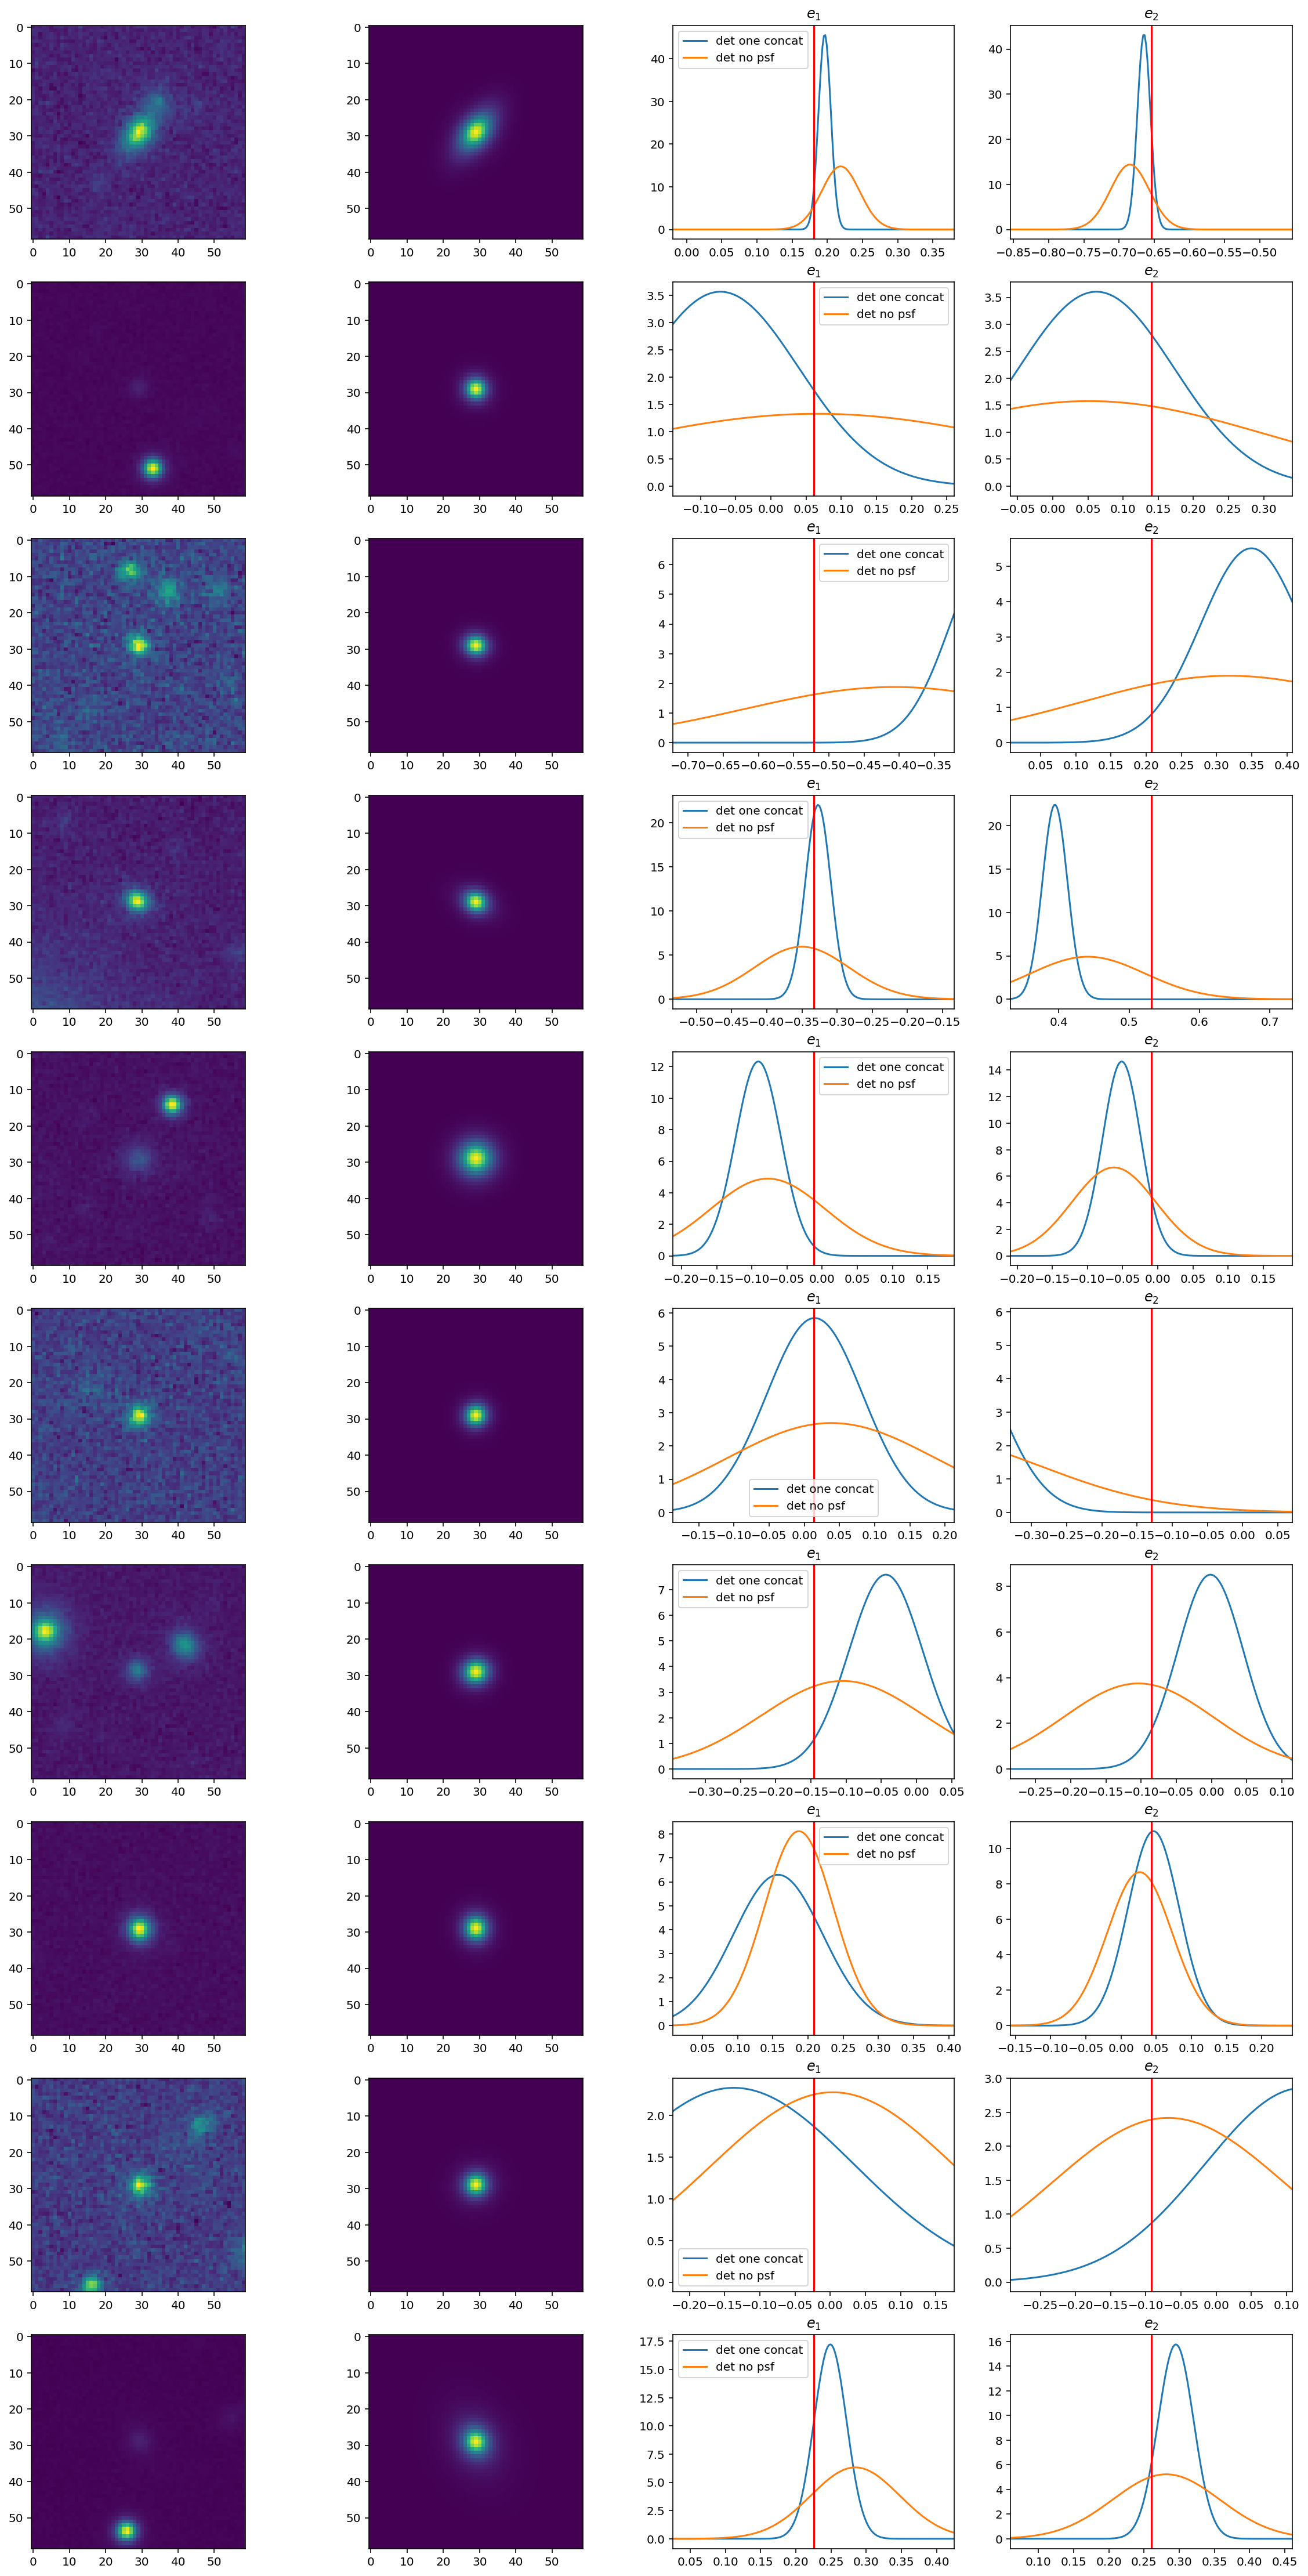

In [28]:
fig, axes = plt.subplots(10,4, figsize = (20, 40))

x = np.linspace(-1,1, 1000)
for i in range (10):
    axes[i,0].imshow(images_noisy[i,:,:,2])
    axes[i,1].imshow(images[i,:,:,2])
    for k in range(2):#3
        _ = axes[i,2].plot(x, gaussian(mean_results_e1[k][i], std_results_e1[k][i]), label = labels[k])
        _ = axes[i,3].plot(x, gaussian(mean_results_e2[k][i], std_results_e2[k][i]), label = labels[k])
    axes[i,2].axvline(-e1[i], color = 'r')
    axes[i,3].axvline(e2[i], color = 'r')
    axes[i,2].set_xlim(-e1[i]-0.2,-e1[i]+0.2)
    axes[i,3].set_xlim(e2[i]-0.2,e2[i]+0.2)
    axes[i,2].set_title('$e_1$')
    axes[i,3].set_title('$e_2$')
    axes[i,2].legend()

#### For BNN: Evaluate aleatoric and epistemic uncertainty

In [15]:
N = 100

image_array = np.zeros((10*N,59,59,6))
psf_array = np.zeros((10*N,59,59,6))

for z in range (N):
    image_array[z*10:(z+1)*10] =  images[:10]
    psf_array[z*10:(z+1)*10] =  psf[:10]
    

output_v1 = model_bnn([tf.cast(image_array, tf.float32), tf.cast(psf_array, tf.float32)])

In [16]:
e1_mean = K.get_value(output_v1.mean())[:,0]
e2_mean = K.get_value(output_v1.mean())[:,1]
e1_std = K.get_value(output_v1.stddev())[:,0]
e2_std = K.get_value(output_v1.stddev())[:,1]


e1_out_mean_bnn = np.zeros((10,N))
e2_out_mean_bnn = np.zeros((10,N))
e1_out_std_bnn = np.zeros((10,N))
e2_out_std_bnn = np.zeros((10,N))

for i in range (N):
    for k in range (10):
        e1_out_mean_bnn[k,i] = e1_mean[k+i*10]
        e2_out_mean_bnn[k,i] = e2_mean[k+i*10]

        e1_out_std_bnn[k,i] = e1_std[k+i*10]
        e2_out_std_bnn[k,i] = e2_std[k+i*10]

In [19]:
N = 100

image_array = np.zeros((10*N,59,59,6))
psf_array = np.zeros((10*N,59,59,6))

for z in range (N):
    image_array[z*10:(z+1)*10] =  images_noisy[:10]
    psf_array[z*10:(z+1)*10] =  psf[:10]
    

output_v1 = model_bnn([tf.cast(image_array, tf.float32), tf.cast(psf_array, tf.float32)])

In [20]:
e1_mean = K.get_value(output_v1.mean())[:,0]
e2_mean = K.get_value(output_v1.mean())[:,1]
e1_std = K.get_value(output_v1.stddev())[:,0]
e2_std = K.get_value(output_v1.stddev())[:,1]


e1_out_mean_bnn_noisy = np.zeros((10,N))
e2_out_mean_bnn_noisy = np.zeros((10,N))
e1_out_std_bnn_noisy = np.zeros((10,N))
e2_out_std_bnn_noisy = np.zeros((10,N))

for i in range (N):
    for k in range (10):
        e1_out_mean_bnn_noisy[k,i] = e1_mean[k+i*10]
        e2_out_mean_bnn_noisy[k,i] = e2_mean[k+i*10]

        e1_out_std_bnn_noisy[k,i] = e1_std[k+i*10]
        e2_out_std_bnn_noisy[k,i] = e2_std[k+i*10]

In [52]:
np.percentile(K.get_value(output_v1[1,0]),97.5)

0.1713763177394867

In [53]:
np.percentile(K.get_value(output_v1[1,0]),2.5)

0.20861881971359253

In [46]:
gal_nb = 6

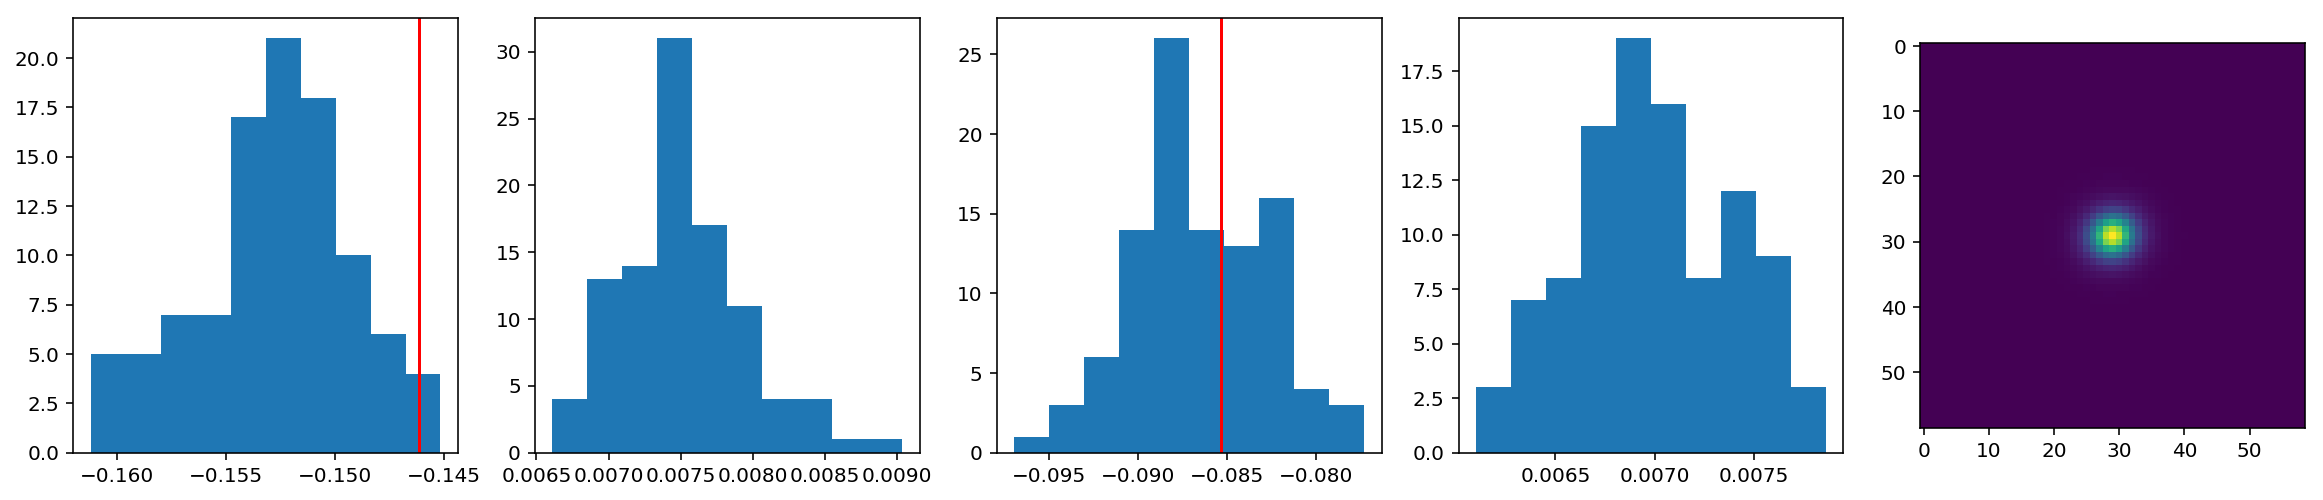

In [47]:
fig, axes = plt.subplots(1,5, figsize = (20,4))
_ = axes[0].hist(e1_out_mean_bnn[gal_nb], bins = 10)
axes[0].axvline(-e1[gal_nb], color = 'r')

_ = axes[1].hist(e1_out_std_bnn[gal_nb], bins = 10)

_ = axes[2].hist(e2_out_mean_bnn[gal_nb], bins = 10)
axes[2].axvline(e2[gal_nb], color = 'r')

_ = axes[3].hist(e2_out_std_bnn[gal_nb], bins = 10)
axes[4].imshow(images[gal_nb,:,:,2])

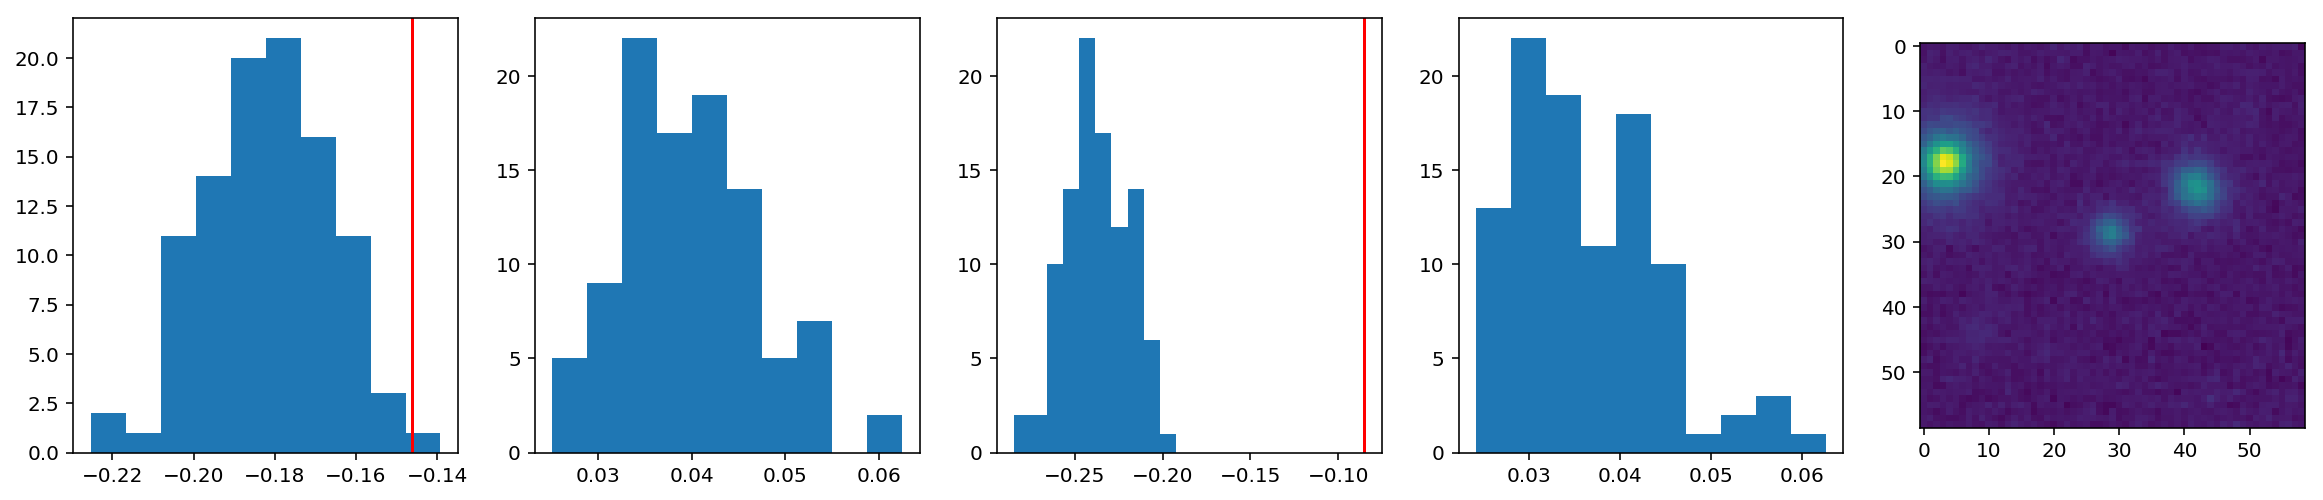

In [48]:
fig, axes = plt.subplots(1,5, figsize = (20,4))
_ = axes[0].hist(e1_out_mean_bnn_noisy[gal_nb], bins = 10)
axes[0].axvline(-e1[gal_nb], color = 'r')

_ = axes[1].hist(e1_out_std_bnn_noisy[gal_nb], bins = 10)

_ = axes[2].hist(e2_out_mean_bnn_noisy[gal_nb], bins = 10)
axes[2].axvline(e2[gal_nb], color = 'r')

_ = axes[3].hist(e2_out_std_bnn_noisy[gal_nb], bins = 10)
axes[4].imshow(images_noisy[gal_nb,:,:,2])

##### Aleatoric and epistemic uncertainties increases with noise and other galaxies on images

Text(0, 0.5, '$\\sigma^{al}_{e_2}$ - $\\sigma^{ep}_{e_2}$')

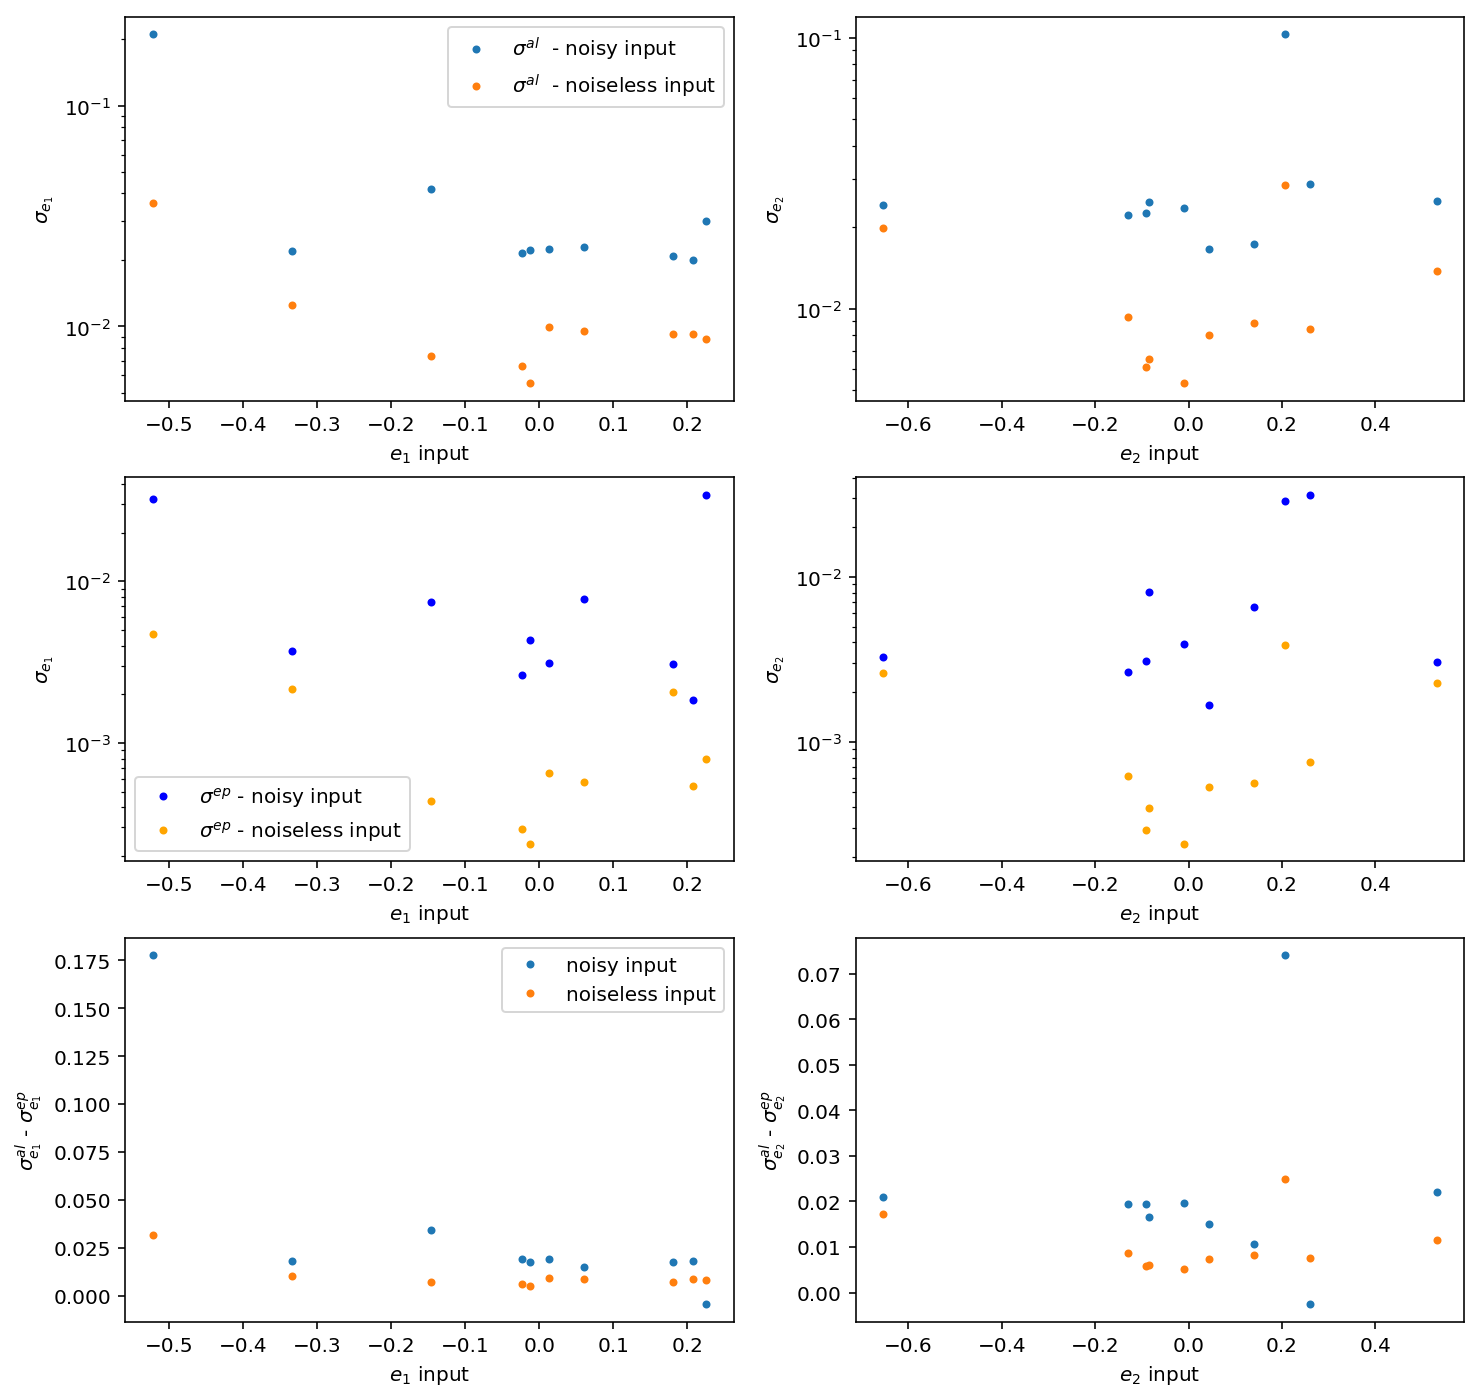

In [92]:
fig, axes = plt.subplots(3,2, figsize = (12,12))

axes[0,0].plot(-e1[:10],e1_out_std_bnn_noisy[:,0], '.', label ="$\sigma^{al}$  - noisy input")
axes[0,0].plot(-e1[:10],e1_out_std_bnn[:,0], '.', label ="$\sigma^{al}$  - noiseless input")
axes[0,0].legend()
axes[0,0].set_xlabel('$e_1$ input')
axes[0,0].set_ylabel('$\sigma_{e_1}$')

axes[0,1].plot(e2[:10],e2_out_std_bnn_noisy[:,0], '.', label ="$\sigma^{al}$  - noisy input")
axes[0,1].plot(e2[:10],e2_out_std_bnn[:,0], '.', label ="$\sigma^{al}$ - noiseless input")
#axes[1].legend()
axes[0,1].set_xlabel('$e_2$ input')
axes[0,1].set_ylabel('$\sigma_{e_2}$')

std_e1_epistemic_noisy=np.zeros((10,))
std_e2_epistemic_noisy=np.zeros((10,))
std_e1_epistemic_noiseless=np.zeros((10,))
std_e2_epistemic_noiseless=np.zeros((10,))
for i in range(10):
    std_e1_epistemic_noisy[i] = np.std(e1_out_std_bnn_noisy[i])
    std_e2_epistemic_noisy[i] = np.std(e2_out_std_bnn_noisy[i])
    std_e1_epistemic_noiseless[i] = np.std(e1_out_std_bnn[i])
    std_e2_epistemic_noiseless[i] = np.std(e2_out_std_bnn[i])
    
axes[1,0].plot(-e1[:10],std_e1_epistemic_noisy, '.', color = 'blue', label ="$\sigma^{ep}$ - noisy input")
axes[1,0].plot(-e1[:10],std_e1_epistemic_noiseless, '.', color = 'orange', label ="$\sigma^{ep}$ - noiseless input")
axes[1,0].legend()
axes[1,0].set_xlabel('$e_1$ input')
axes[1,0].set_ylabel('$\sigma_{e_1}$')

axes[1,1].plot(e2[:10],std_e2_epistemic_noisy, '.',color = 'blue', label ="$\sigma^{ep}$ - noisy input")
axes[1,1].plot(e2[:10],std_e2_epistemic_noiseless, '.',color = 'orange', label ="$\sigma^{ep}$ - noiseless input")
#axes[1].legend()
axes[1,1].set_xlabel('$e_2$ input')
axes[1,1].set_ylabel('$\sigma_{e_2}$')

axes[0,0].set_yscale('log')
axes[0,1].set_yscale('log')
axes[1,0].set_yscale('log')
axes[1,1].set_yscale('log')


axes[2,0].plot(-e1[:10], e1_out_std_bnn_noisy[:,0] - std_e1_epistemic_noisy, '.', label = 'noisy input')
axes[2,0].plot(-e1[:10], e1_out_std_bnn[:,0] - std_e1_epistemic_noiseless, '.', label = 'noiseless input')
axes[2,0].set_xlabel('$e_1$ input')
axes[2,0].set_ylabel('$\sigma^{al}_{e_1}$ - $\sigma^{ep}_{e_1}$')
axes[2,0].legend()

axes[2,1].plot(e2[:10], e2_out_std_bnn_noisy[:,0] - std_e2_epistemic_noisy, '.', label = 'noisy input')
axes[2,1].plot(e2[:10], e2_out_std_bnn[:,0] - std_e2_epistemic_noiseless, '.', label = 'noiseless input')
axes[2,1].set_xlabel('$e_2$ input')
axes[2,1].set_ylabel('$\sigma^{al}_{e_2}$ - $\sigma^{ep}_{e_2}$')


Epistemic uncertainty smaller than aleatoric one here, even when tested on noisy images.

##### Only one case where epistemic uncertainty is higher than aleatoric for the noisy image:

In [95]:
np.where((e2[:10]<0.3) & (e2[:10]>0.21))

(array([9]),)

In [99]:
e1_out_mean_bnn_noisy.shape

(10, 100)

In [109]:
img_nb = 9

e1 is equal to: 0.22536707340490528 and e2 : 0.2605989087122399


W0308 16:14:30.532709 140616500864832 legend.py:1289] No handles with labels found to put in legend.


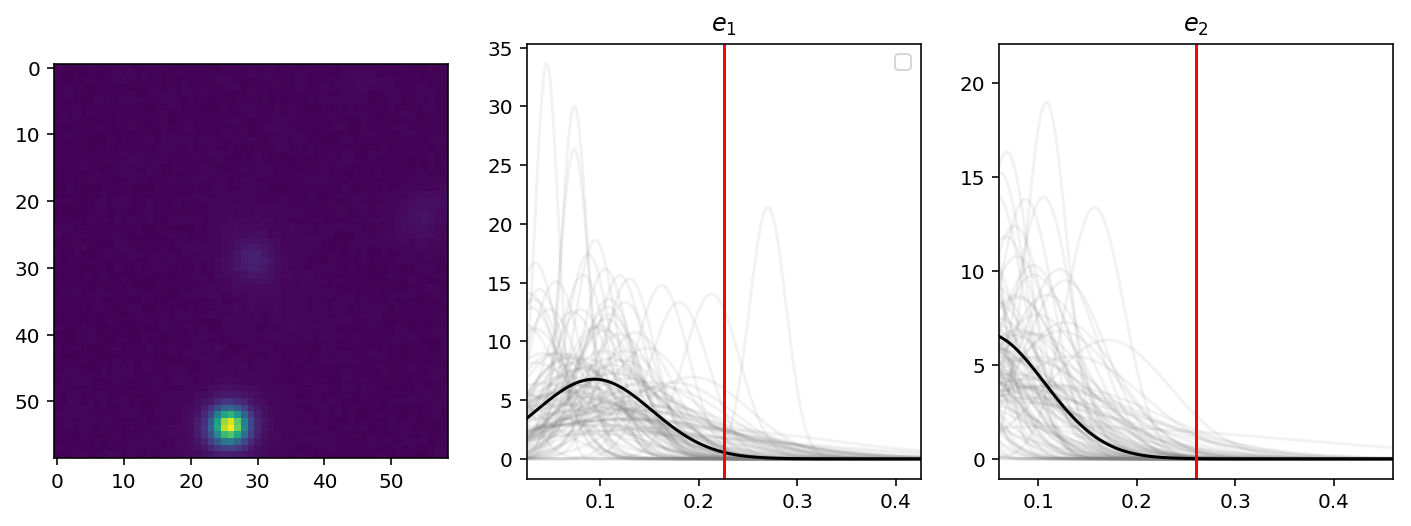

In [110]:
print('e1 is equal to: ' +str(-e1[img_nb])+' and e2 : '+str(e2[img_nb]))
fig, axes = plt.subplots(1,3, figsize = (12,4))
axes[0].imshow(images_noisy[img_nb,:,:,2])

x = np.linspace(-1,1, 1000)

for i in range (100):   
    axes[1].plot(x, gaussian(e1_out_mean_bnn_noisy[img_nb,i], e1_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1)   
    axes[2].plot(x, gaussian(e2_out_mean_bnn_noisy[img_nb,i], e2_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1)

axes[1].plot(x, gaussian(np.mean(e1_out_mean_bnn_noisy[img_nb,:]), np.mean(e1_out_std_bnn_noisy[img_nb,:])), color = 'black', alpha = 1)   
axes[2].plot(x, gaussian(np.mean(e2_out_mean_bnn_noisy[img_nb,:]), np.mean(e2_out_std_bnn_noisy[img_nb,:])), color = 'black', alpha = 1)
    

axes[1].axvline(-e1[img_nb], color = 'r')
axes[2].axvline(e2[img_nb], color = 'r')
axes[1].set_xlim(-e1[img_nb]-0.2,-e1[img_nb]+0.2)
axes[2].set_xlim(e2[img_nb]-0.2,e2[img_nb]+0.2)
axes[1].set_title('$e_1$')
axes[2].set_title('$e_2$')
axes[1].legend()

Could be understood as a very bright galaxy is on the image, something that the model is troubling to deal with as it did not see this in its training set.

e1 is equal to: 0.18072651633781117 and e2 : -0.6539580728323495
e1 is equal to: 0.06084804362534251 and e2 : 0.14031417760970927
e1 is equal to: -0.521462974011675 and e2 : 0.2074555027714428
e1 is equal to: -0.33328399117823243 and e2 : 0.5317118803028609
e1 is equal to: -0.01210057182763586 and e2 : -0.009122904136179165
e1 is equal to: 0.013294338554872321 and e2 : -0.1295201308709439
e1 is equal to: -0.14613260640641598 and e2 : -0.08536828664117768
e1 is equal to: 0.20806321628873464 and e2 : 0.04310568219222864
e1 is equal to: -0.023471736093119512 and e2 : -0.09209458448263035
e1 is equal to: 0.22536707340490528 and e2 : 0.2605989087122399


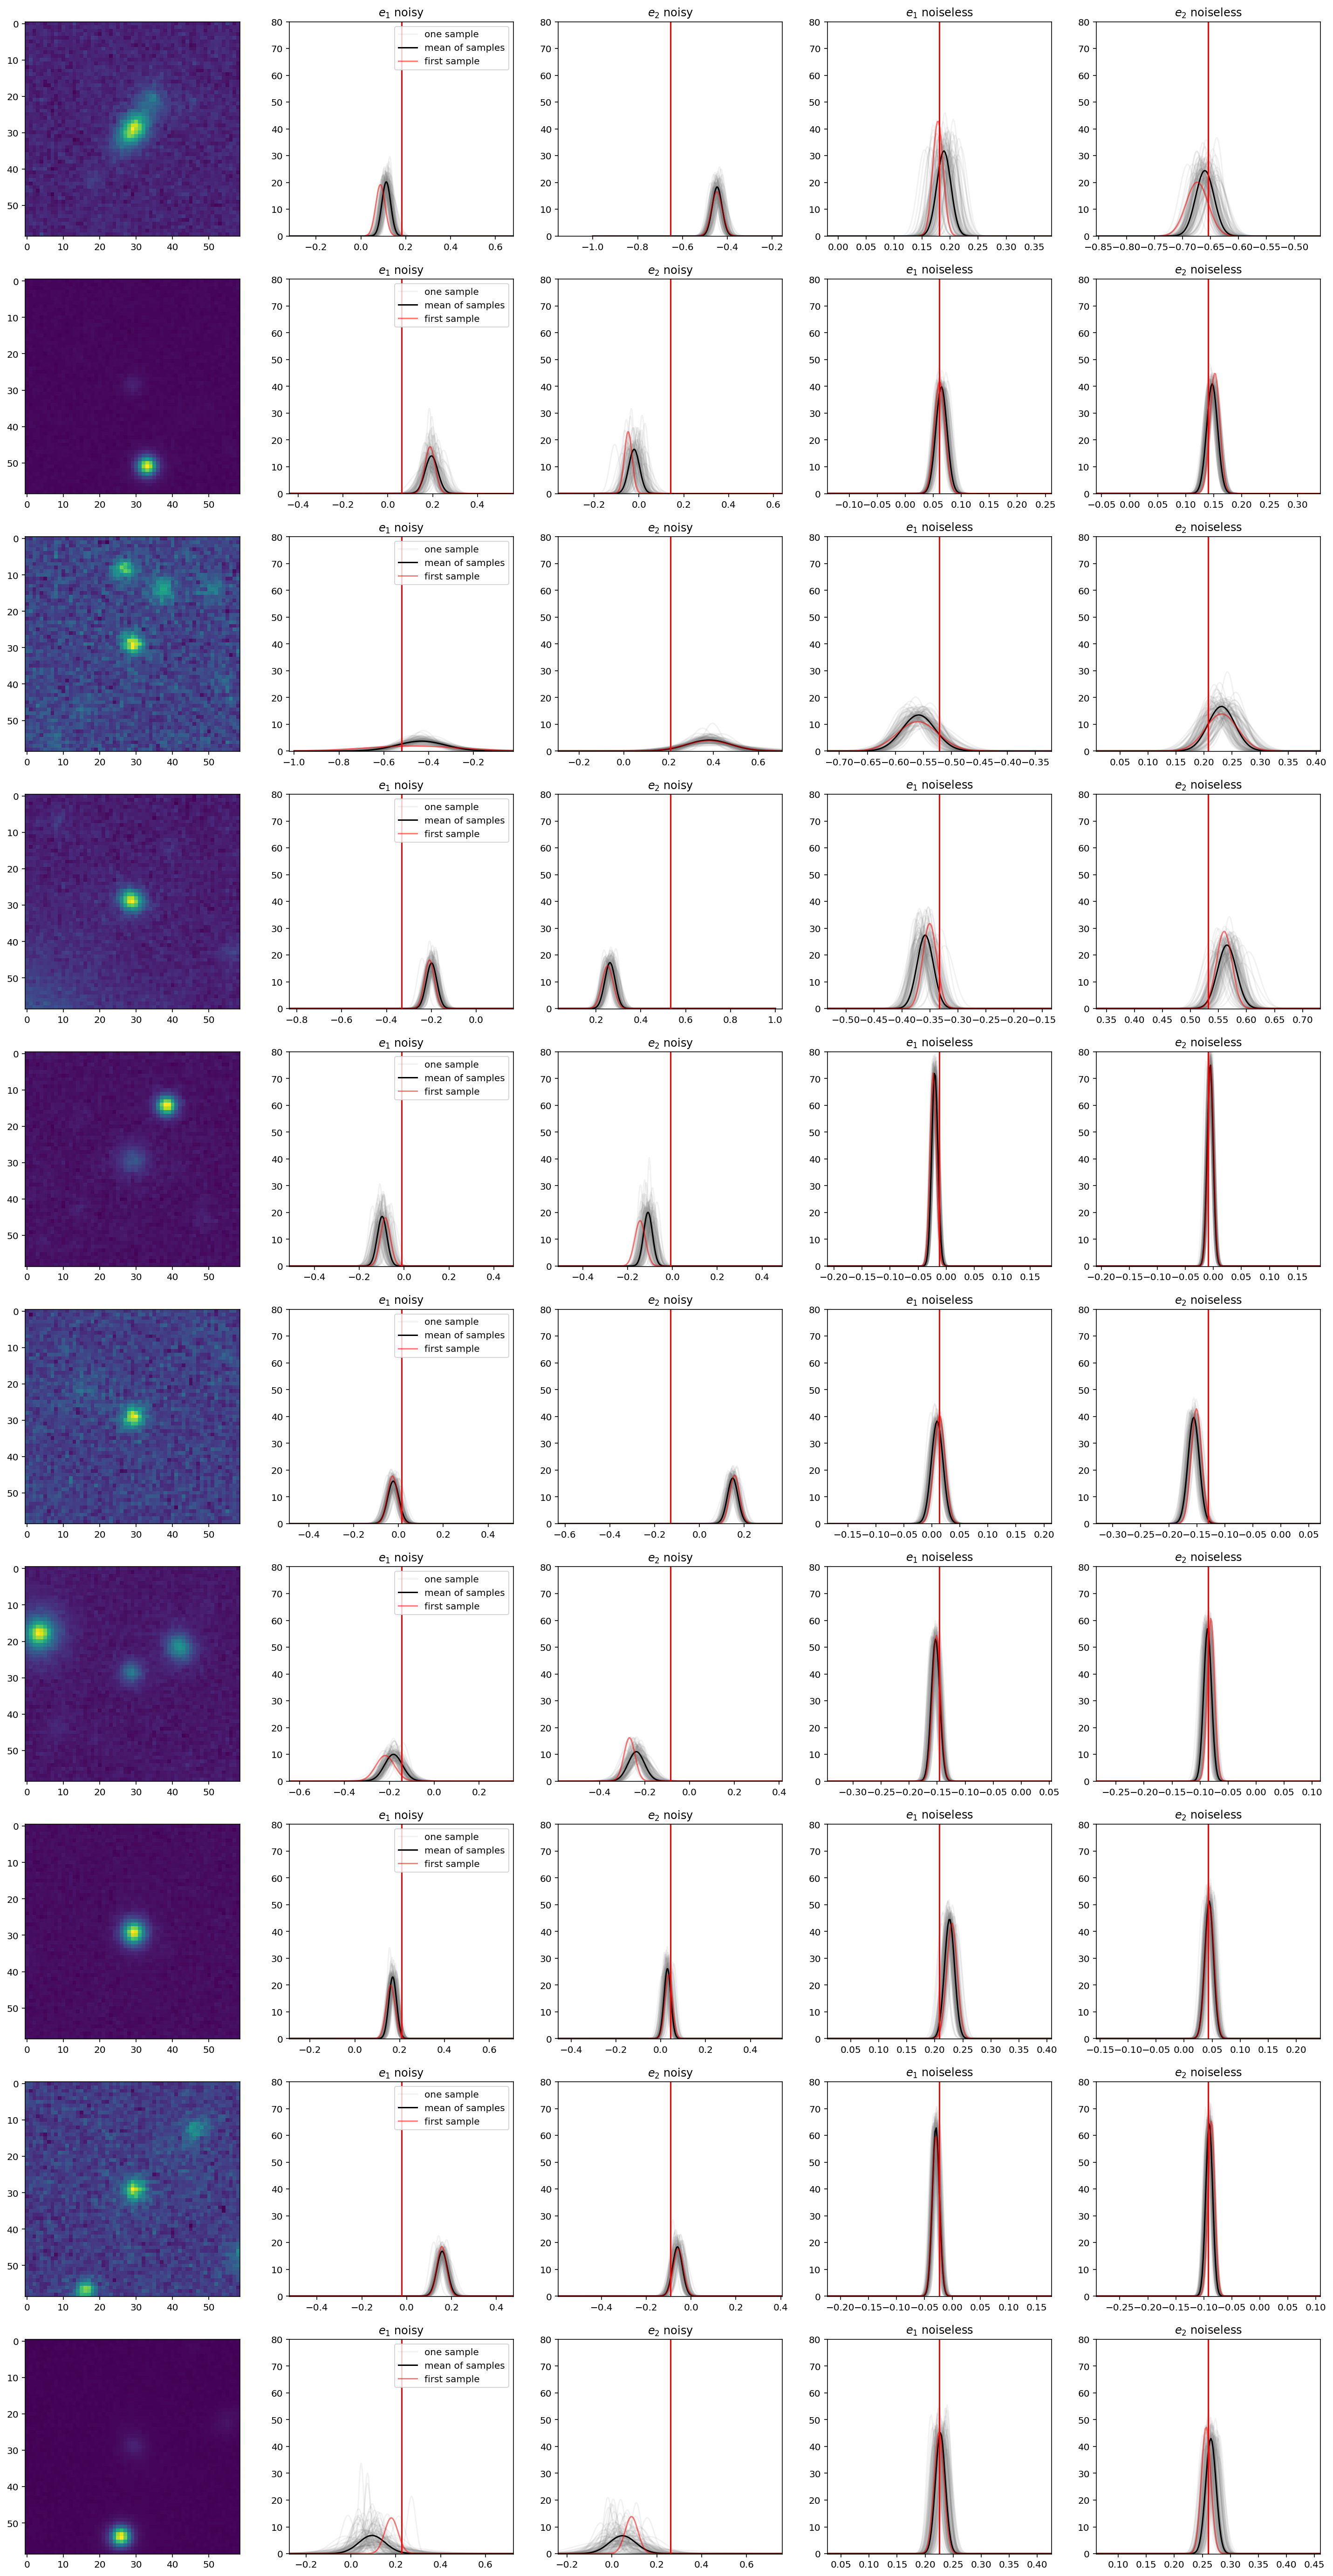

In [122]:
fig, axes = plt.subplots(10,5, figsize = (25,50))

x = np.linspace(-1,1, 1000)
for img_nb in range (10):
    print('e1 is equal to: ' +str(-e1[img_nb])+' and e2 : '+str(e2[img_nb]))
    axes[img_nb,0].imshow(images_noisy[img_nb,:,:,2])
    for i in range (100):   
         
        axes[img_nb,2].plot(x, gaussian(e2_out_mean_bnn_noisy[img_nb,i], e2_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1)
        axes[img_nb,3].plot(x, gaussian(e1_out_mean_bnn[img_nb,i], e1_out_std_bnn[img_nb,i]), color = 'grey', alpha = 0.1)   
        axes[img_nb,4].plot(x, gaussian(e2_out_mean_bnn[img_nb,i], e2_out_std_bnn[img_nb,i]), color = 'grey', alpha = 0.1)
        if i == 99:
            axes[img_nb,1].plot(x, gaussian(e1_out_mean_bnn_noisy[img_nb,i], e1_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1, label = 'one sample')  
        else:
            axes[img_nb,1].plot(x, gaussian(e1_out_mean_bnn_noisy[img_nb,i], e1_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1)  

    axes[img_nb,1].plot(x, gaussian(np.mean(e1_out_mean_bnn_noisy[img_nb,:]), np.mean(e1_out_std_bnn_noisy[img_nb,:])), color = 'black', alpha = 1, label = 'mean of samples')   
    axes[img_nb,2].plot(x, gaussian(np.mean(e2_out_mean_bnn_noisy[img_nb,:]), np.mean(e2_out_std_bnn_noisy[img_nb,:])), color = 'black', alpha = 1)
    axes[img_nb,3].plot(x, gaussian(np.mean(e1_out_mean_bnn[img_nb,:]), np.mean(e1_out_std_bnn[img_nb,:])), color = 'black', alpha = 1)   
    axes[img_nb,4].plot(x, gaussian(np.mean(e2_out_mean_bnn[img_nb,:]), np.mean(e2_out_std_bnn[img_nb,:])), color = 'black', alpha = 1)
    
    axes[img_nb,1].plot(x, gaussian(e1_out_mean_bnn_noisy[img_nb,0], e1_out_std_bnn_noisy[img_nb,0]), color = 'red', alpha = 0.5, label = 'first sample')   
    axes[img_nb,2].plot(x, gaussian(e2_out_mean_bnn_noisy[img_nb,0], e2_out_std_bnn_noisy[img_nb,0]), color = 'red', alpha = 0.5)
    axes[img_nb,3].plot(x, gaussian(e1_out_mean_bnn[img_nb,0], e1_out_std_bnn[img_nb,0]), color = 'red', alpha = 0.5)   
    axes[img_nb,4].plot(x, gaussian(e2_out_mean_bnn[img_nb,0], e2_out_std_bnn[img_nb,0]), color = 'red', alpha = 0.5)


    axes[img_nb,1].axvline(-e1[img_nb], color = 'r')
    axes[img_nb,2].axvline(e2[img_nb], color = 'r')
    axes[img_nb,1].set_xlim(-e1[img_nb]-0.5,-e1[img_nb]+0.5)
    axes[img_nb,2].set_xlim(e2[img_nb]-0.5,e2[img_nb]+0.5)
    axes[img_nb,1].set_title('$e_1$ noisy')
    axes[img_nb,2].set_title('$e_2$ noisy')
    axes[img_nb,1].legend()
    
    axes[img_nb,3].axvline(-e1[img_nb], color = 'r')
    axes[img_nb,4].axvline(e2[img_nb], color = 'r')
    axes[img_nb,3].set_xlim(-e1[img_nb]-0.2,-e1[img_nb]+0.2)
    axes[img_nb,4].set_xlim(e2[img_nb]-0.2,e2[img_nb]+0.2)
    axes[img_nb,3].set_title('$e_1$ noiseless')
    axes[img_nb,4].set_title('$e_2$ noiseless')
    
    
    axes[img_nb,1].set_ylim(-0.1,80)
    axes[img_nb,2].set_ylim(-0.1,80)
    axes[img_nb,3].set_ylim(-0.1,80)
    axes[img_nb,4].set_ylim(-0.1,80)

In [130]:
print(np.mean(-e1[:1000]), np.mean(e1_out_mean_bnn))
print(np.mean(e2[:1000]), np.mean(e2_out_mean_bnn))

-0.005986517713405567 -0.04033749734982848
-0.006380757265538057 0.025477743778377773


In [136]:
np.average(e1_out_mean_no_psf, weights=1/e1_out_std_no_psf)

-0.007877187441171147

In [137]:
np.average(e2_out_mean_no_psf, weights=1/e2_out_std_no_psf)

-0.01138578500863725

## Shear bias estimation

In [201]:
def boxplot_func_shear_bias(df_in, x,ell, y, z,shear,
            xlim, ylim, ylim2, 
            x_scale, 
            legend,
            x_label, y_label, y_label_hist, y_label_2,
            errors = None,
            legend_remove = False,
            palette = ["#3498db","#e74c3c"],
            nbins = 11):
    
    m = []
    c = []
    err = []
    
    import matplotlib as mpl
    mpl.rcdefaults()
    
    if errors is not None:
        df_plot = df_in.drop(errors)
    else:
        df_plot = df_in

    df_plot = df_plot.dropna()
    print(len(df_plot))
    if x_scale == 'log':
        x_bins = np.geomspace(xlim[0], xlim[1], nbins+1)
    else :
        x_bins = np.linspace(xlim[0], xlim[1], nbins+1)
    
    x_bins[0] -= 1e-5
    x_bins[-1] += 1e-5
    
    idx = np.digitize(df_plot[x], x_bins)
    
    fig, axes = plt.subplots(3,1, figsize=(5,4), gridspec_kw={'height_ratios': [1, 3,2]})
    
    if x_scale == 'log':
        sns.distplot(np.log10(df_plot[x]), ax=axes[0], color='0.8')
        axes[0].set_xlim(np.log10(xlim[0]), np.log10(xlim[1]))
    else:
        sns.distplot(df_plot[x], ax=axes[0], color='0.8')
        axes[0].set_xlim(xlim[0], xlim[1])
    
    axes[0].set_yticks([])
    axes[0].set_ylabel(y_label_hist)
    axes[0].set_xticks([])
#####
    print(idx, len(idx))
    exp = np.unique(df_plot[z])
    N_exp = len(exp)
    handles = []
    for ik, key in enumerate(exp):
        stats = {}
        for i in range(1,len(x_bins)):
            xx = df_plot[ell][np.logical_and(idx==i,df_plot[z]==key)].values+df_plot[shear][np.logical_and(idx==i,df_plot[z]==key)].values
            yy = df_plot[y][np.logical_and(idx==i,df_plot[z]==key)].values
            slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(xx,yy)

            m.append(slope-1)
            c.append(intercept)
            err.append(std_err)
        handles = exp
        #plt.setp(key, color=palette[ik])
#####        
    
    ax = axes[1]
    #ax = ax.twiny()
    ax.axhline(y=0, c='0.5', zorder=32, lw=0.5)
    med_array = np.array(m).reshape(N_exp,int(len(m)/N_exp))
    for ik, key in enumerate(exp):
        ax.plot(np.repeat(x_bins,2)[1:-1], np.repeat(med_array[ik],2), c=palette[ik])
    ax.set_xlim(xlim[0], xlim[1])
    if x_scale == 'log':
        ax.set_xscale('log')
    #ax.set_xlim(xlim[0], xlim[1])
    ax.set_xlabel(x_label)
    ax.set_ylim(ylim)
    ax.set_ylabel(y_label)
    ax.xaxis.tick_bottom()
    if not legend_remove:
        ax.legend(handles, legend, frameon=False, loc ='upper right', borderpad = 0.1, fontsize = 10)
           
    fig.align_ylabels(axes)    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    
    
    ax = axes[2]
    #ax = ax.twiny()
    ax.axhline(y=0, c='0.5', zorder=32, lw=0.5)
    med_array = np.array(c).reshape(N_exp,int(len(c)/N_exp))
    for ik, key in enumerate(exp):
        ax.plot(np.repeat(x_bins,2)[1:-1], np.repeat(med_array[ik],2), c=palette[ik])
    ax.set_xlim(xlim[0], xlim[1])
    if x_scale == 'log':
        ax.set_xscale('log')
    ax.set_xlabel(x_label)
    ax.set_ylim(ylim2)
    ax.set_ylabel(y_label_2)
    ax.xaxis.tick_bottom()
            
    fig.align_ylabels(axes)    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    
    return fig , m,c,err

Shear bias: $i = 1,2$


$〈\epsilon_{i,obs}〉=g_{i,obs}=c_i+(1+m_i)g_i$


$g_{i,obs}=c_i+(1+m_i)(〈\epsilon_{i,int}〉+g_i)$

source (https://hal-cea.archives-ouvertes.fr/cea-02949701/document)

or $1+m_i=〈R_{ii}〉$ 

with $ R_{αβ} ≈ \frac{e_{obs,+α}−e_{obs,−α}}{2∆g_β}$ , source (https://www.aanda.org/articles/aa/pdf/2019/01/aa33740-18.pdf)

In [140]:
df_v1 = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

In [141]:
df_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
id                10000 non-null int64
e1                10000 non-null float64
e2                10000 non-null float64
shear_1           10000 non-null float64
shear_2           10000 non-null float64
redshift          10000 non-null float64
redshift_true     10000 non-null float64
blendedness       9999 non-null float64
snr_r             9998 non-null float64
convergence       10000 non-null float64
e1_hsm_regauss    9976 non-null float64
e2_hsm_regauss    9976 non-null float64
mag_r_meas        9998 non-null float64
mag_r_true        10000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


In [147]:
df_v2 = df_v1[(np.abs(df_v1['e1'])<=0.1)]

df_v2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6841 entries, 1 to 9999
Data columns (total 14 columns):
id                6841 non-null int64
e1                6841 non-null float64
e2                6841 non-null float64
shear_1           6841 non-null float64
shear_2           6841 non-null float64
redshift          6841 non-null float64
redshift_true     6841 non-null float64
blendedness       6840 non-null float64
snr_r             6839 non-null float64
convergence       6841 non-null float64
e1_hsm_regauss    6827 non-null float64
e2_hsm_regauss    6827 non-null float64
mag_r_meas        6839 non-null float64
mag_r_true        6841 non-null float64
dtypes: float64(13), int64(1)
memory usage: 801.7 KB


In [148]:
df_v2.index

Int64Index([   1,    4,    5,    6,    8,   11,   12,   13,   14,   15,
            ...
            9987, 9989, 9990, 9991, 9992, 9993, 9995, 9997, 9998, 9999],
           dtype='int64', length=6841)

In [152]:
df_v1['e1'][2]

-0.2746974329727165

In [156]:
df_v1['e1'][1]

0.03013658390191807

In [155]:
df_v2['e1'][1]

0.03013658390191807

In [157]:
df_v2['e1'][4], df_v1['e1'][4]

(-0.005709342233080301, -0.005709342233080301)

In [158]:
df_v2['e1'][2]

KeyError: 2

In [241]:
df_plot_hsm = pd.DataFrame()

df_v1 = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')


e_hsm = np.sqrt(-data['e1_hsm_regauss'][:nb_of_points]**2 + data['e2_hsm_regauss'][:nb_of_points]**2)

e = np.sqrt(e1**2+e2**2)
e_out = np.sqrt(e1_out_mean**2+e2_out_mean**2)

df_plot_hsm = pd.concat([df_v1[:nb_of_points], df_v1[:nb_of_points]], ignore_index=True, sort = True)
df_plot_hsm['e_error']=np.concatenate([e_out - e[:nb_of_points], e_hsm-e[:nb_of_points]])
df_plot_hsm['e']=np.concatenate([e[:nb_of_points],e[:nb_of_points]])

df_plot_hsm['exp'] = [1]*nb_of_points + [2]*nb_of_points

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in sqrt
  


In [139]:
df_plot_hsm['e1_meas']= np.concatenate([e1_out_mean, data['e1_hsm_regauss'][:nb_of_points]])
df_plot_hsm['e2_meas']= np.concatenate([e2_out_mean, data['e2_hsm_regauss'][:nb_of_points]])
df_plot_hsm['e1_sheared'] = np.concatenate([-e1[:nb_of_points],-e1[:nb_of_points]])
df_plot_hsm['e2_sheared'] = np.concatenate([e2[:nb_of_points],e2[:nb_of_points]])

NameError: name 'df_plot_hsm' is not defined

In [243]:
ellipticity = calc_lensed_ellipticity(-df_plot_hsm['e1'].values, df_plot_hsm['e2'].values, 0,0, 0)

In [244]:
df_plot_hsm['e1_conv'] = ellipticity_conversion(df_plot_hsm['e1'])
df_plot_hsm['e2_conv'] = ellipticity_conversion(df_plot_hsm['e2'])

In [245]:
np.min(df_plot_hsm['snr_r'])

39.86887204889025

1527
[6 1 1 ... 7 3 5] 1527


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)


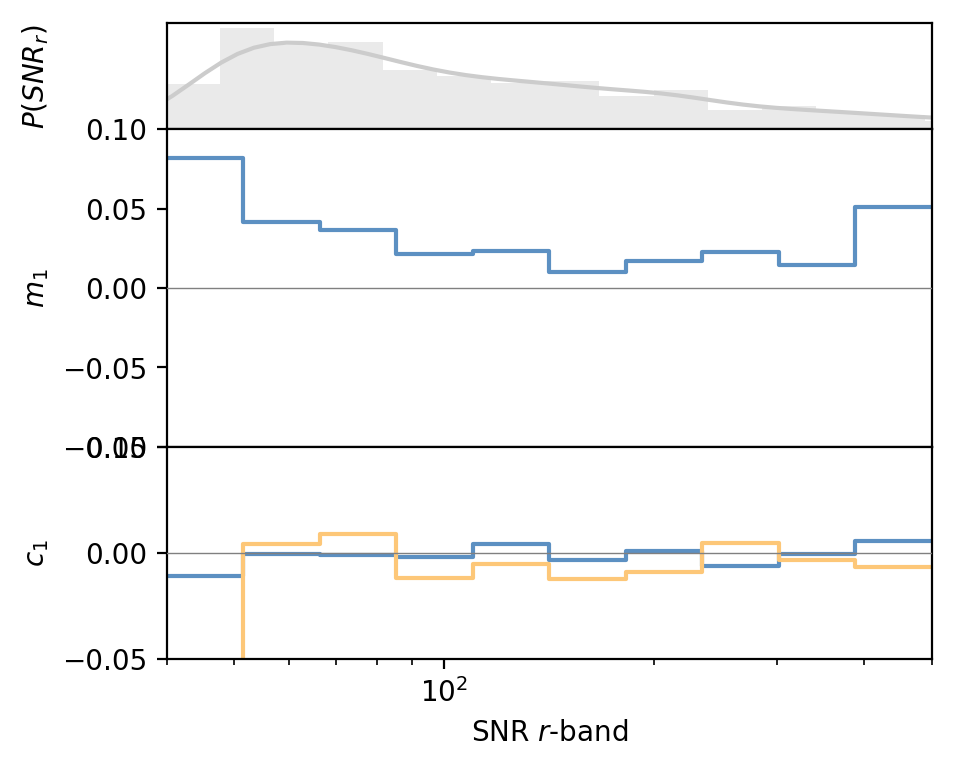

In [247]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'snr_r', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (40, 500),
              ylim = (-0.1,0.1), 
              ylim2 = (-0.05, 0.05), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'HSM'],
              x_label='SNR $r$-band', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.35]),
              nbins = 10)

1996
[5 0 0 ... 1 2 5] 1996


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)


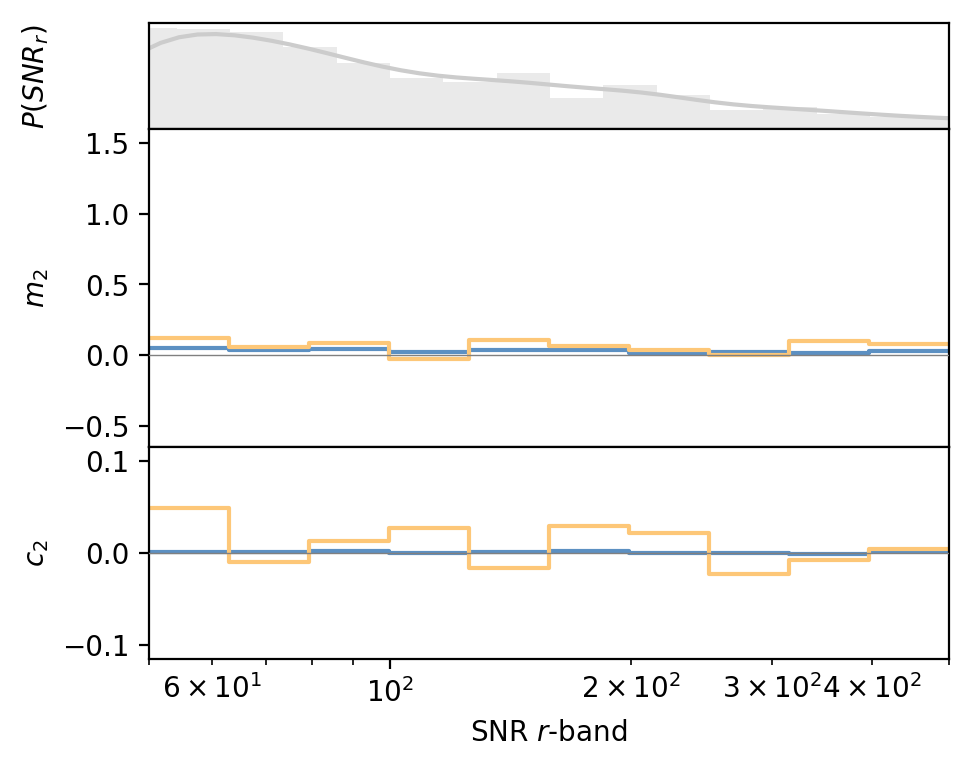

In [214]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'snr_r', ell = 'e2_conv', y = 'e2_meas', z = 'exp', shear = 'shear_2',
              xlim = (50, 500),
              ylim = (-0.65,1.6), 
              ylim2 = (-0.115, 0.115), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'HSM'],
              x_label='SNR $r$-band', 
              y_label = '$m_2$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_2$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,.35]),#0.35,
              nbins = 10)

In [249]:
df_plot_hsm_2 = df_plot_hsm[(df_plot_hsm['blendedness']>0.0000001)]

1157
[3 8 6 ... 9 4 4] 1157


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)


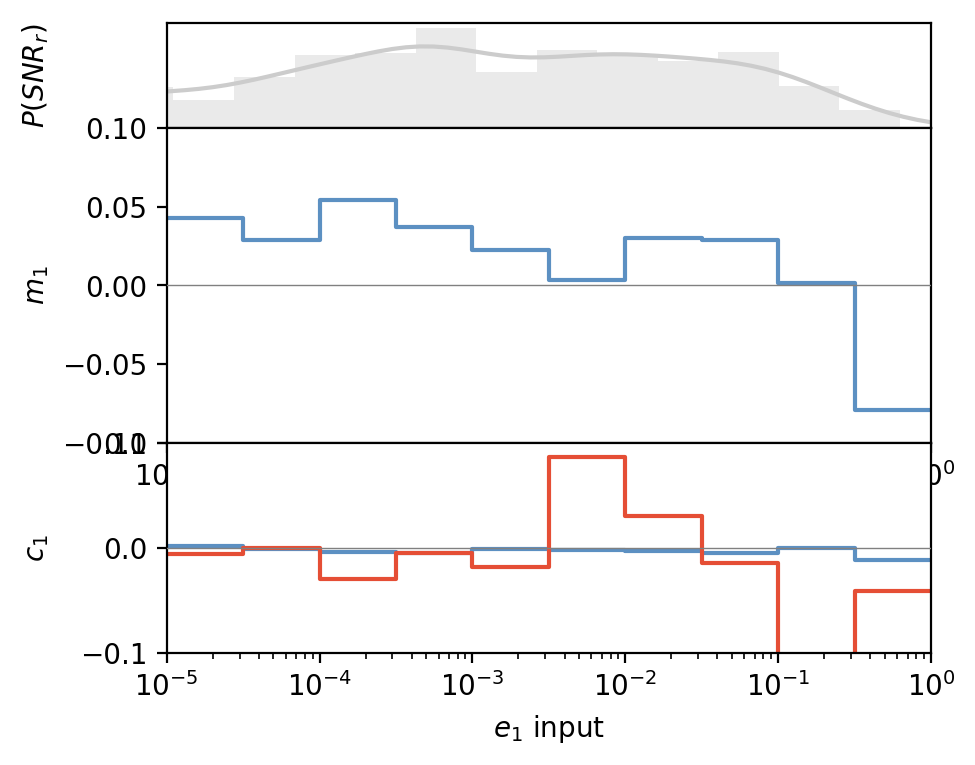

In [252]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm_2, 
              x = 'blendedness', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (0.00001, 1),
              ylim = (-0.1,0.1), 
              ylim2 = (-0.1, 0.1), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'HSM'],
              x_label='$e_1$ input', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)

1996
[4 5 9 ... 6 8 6] 1996


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)


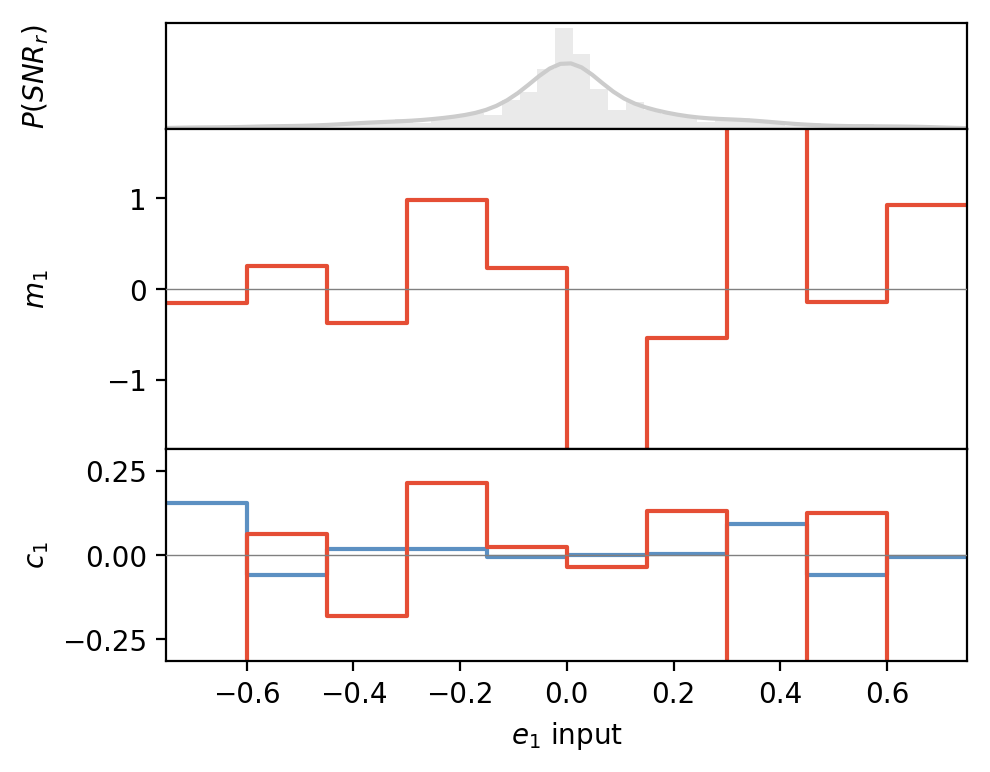

In [215]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'e1_conv', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (-0.75, 0.75),
              ylim = (-1.76,1.76), 
              ylim2 = (-0.315, 0.315), 
              x_scale = 'linear',
              legend = ['network cut 24.5', 'HSM'],
              x_label='$e_1$ input', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)